# Awas river flow vs Rainfall correlation

Rainfall Data Statistical Summary (1990-2022):
       January  February   March   April     May    June    July  August  \
count    33.00     33.00   33.00   33.00   33.00   33.00   33.00   33.00   
mean      9.61     22.52   40.49   74.54   67.60  138.21  267.53  268.68   
std      13.10     31.92   30.99   47.62   46.09   54.59   78.94   78.09   
min       0.00      0.00    0.00    5.27    0.00   47.46  116.02  131.84   
25%       0.00      0.00   21.09   36.91   26.37  100.20  237.30  221.48   
50%       0.00     10.55   36.91   68.55   68.55  137.11  258.40  290.04   
75%      15.82     36.91   58.01   94.92  102.42  163.48  321.68  321.68   
max      47.46    142.38  137.11  210.94  168.75  284.77  474.61  469.34   

       September  October  November  December  
count      33.00    33.00     33.00     33.00  
mean      139.35    36.89      8.16      5.64  
std        72.43    39.80     13.15      8.50  
min        42.19     0.00      0.00      0.00  
25%        84.38     5.27   

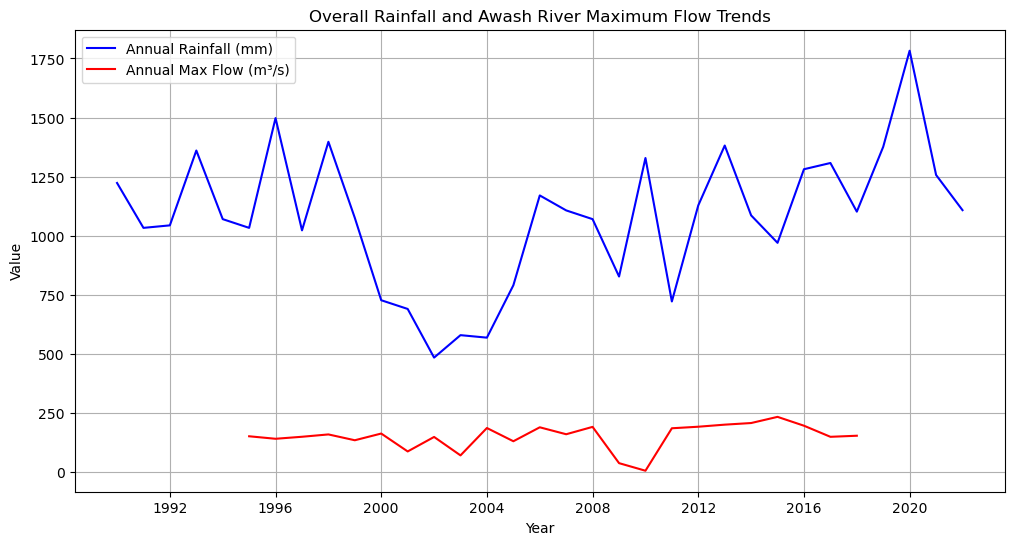

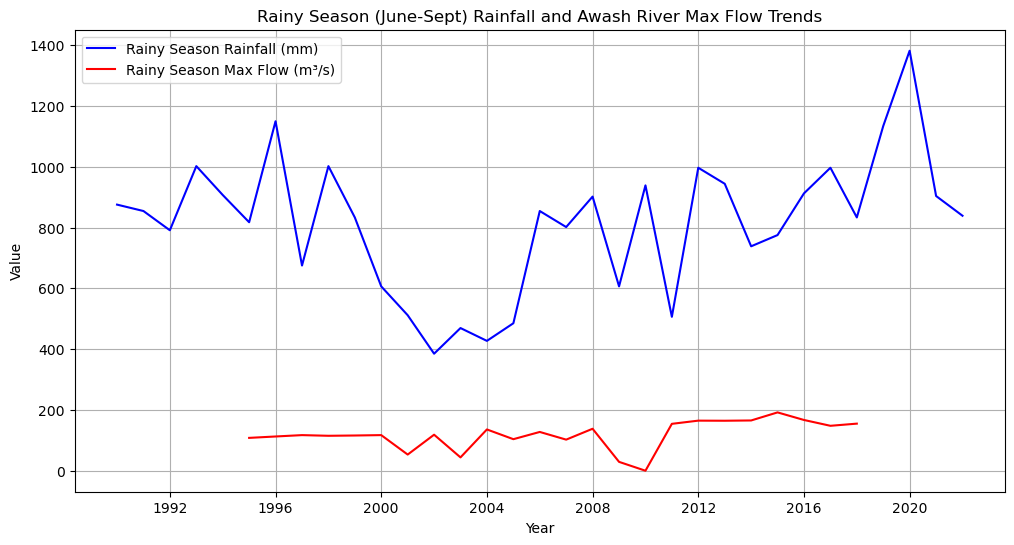

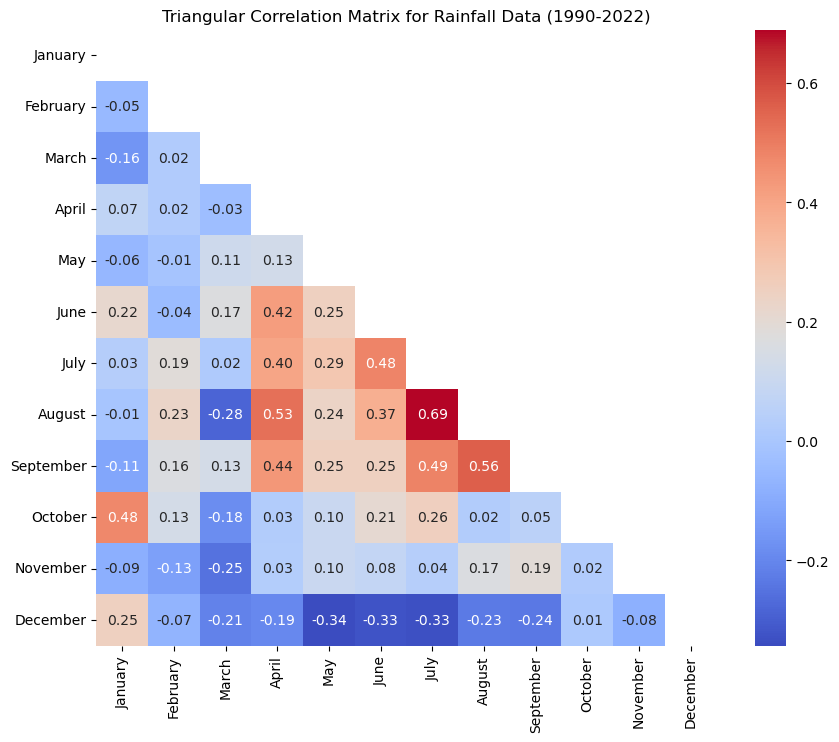


Conclusions:
1. The rainfall data and Awash River maximum flow data were successfully interpolated to fill missing values.
2. Statistical analysis shows the overall trend and seasonal distribution of rainfall and river flow.
3. The overall trend graphs indicate a potential relationship between rainfall and river flow over the years.
4. Rainy season (June-September) trends highlight the critical period for rainfall and its impact on the river flow.
5. The correlation matrix reveals the interdependence of rainfall across months, providing insights into seasonal patterns.

Correlation between Rainfall and River Flow (June–September): 0.24


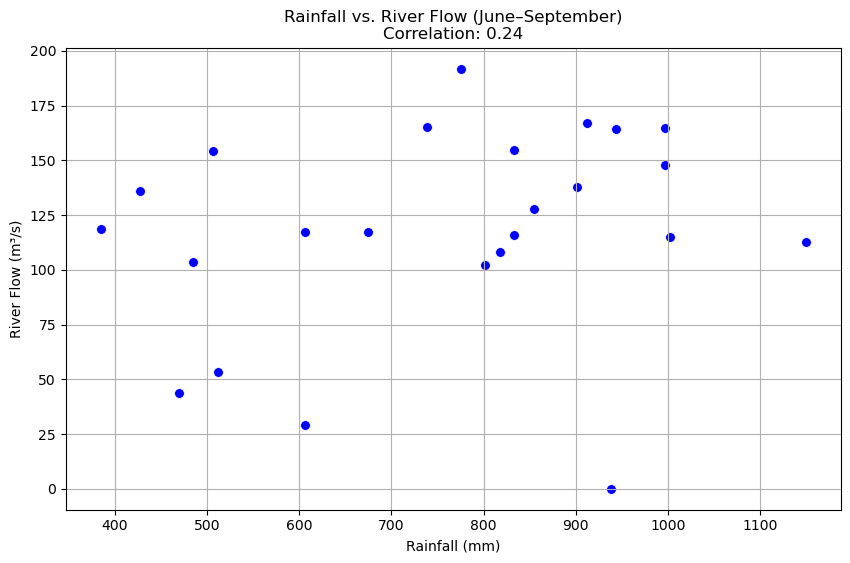

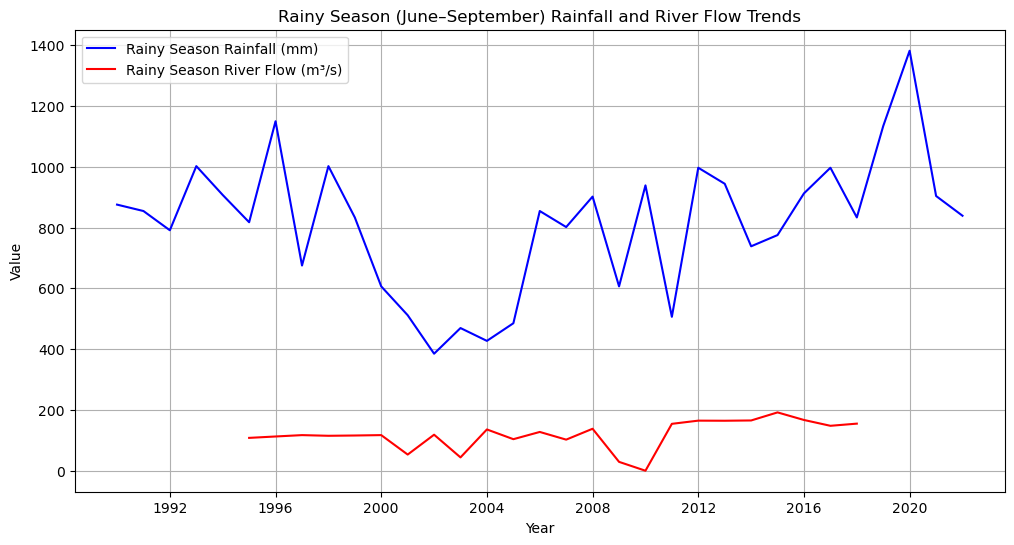

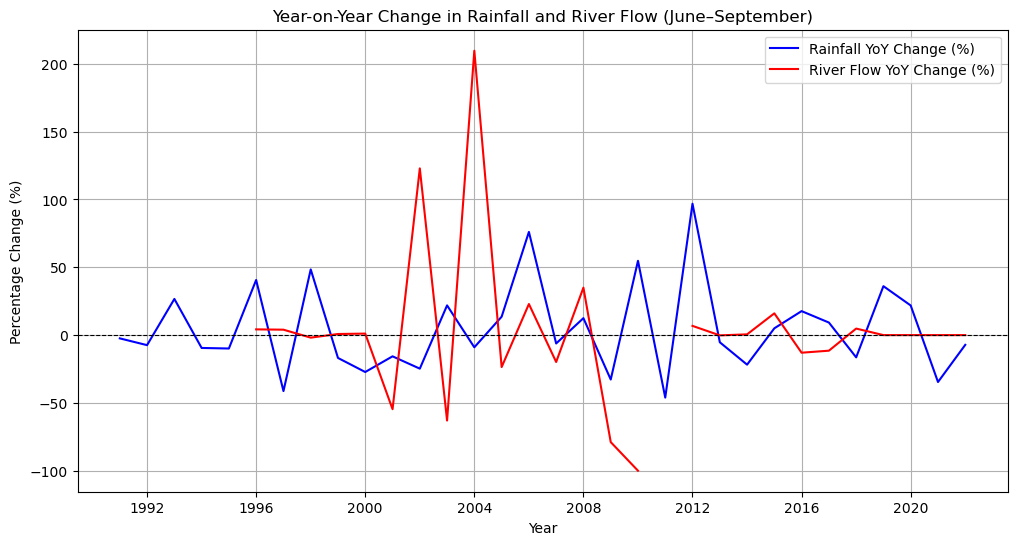


Rainy Season (June–September) Analysis:
1. The correlation coefficient between rainfall and river flow during the rainy season is 0.24.
   - This indicates a weak relationship.
2. Scatter plot visualization shows the nature of the relationship, which is non-linear.
3. Line plots indicate that both rainfall and river flow follow a similar trend over the years, with notable fluctuations in certain years.
4. Year-on-year percentage change analysis highlights significant annual variability in both rainfall and river flow.



In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
rainfall_data_path = r"C:\Users\Jifara\anaconda3\envs\SWToolbox\precipitation_data.csv"
flow_data_path = r"C:\Users\Jifara\anaconda3\envs\SWToolbox\AwashBelo_MaximumFlow.csv"

# Read the rainfall data
rainfall_data = pd.read_csv(rainfall_data_path)
flow_data = pd.read_csv(flow_data_path)

# 1. Interpolate for missing data
# Convert 'Year' column to datetime and set index for both datasets
rainfall_data['Year'] = pd.to_datetime(rainfall_data['Year'], format='%Y')
rainfall_data.set_index('Year', inplace=True)

flow_data['Year'] = pd.to_datetime(flow_data['Year'], format='%Y')
flow_data.set_index('Year', inplace=True)

# Interpolate missing values for rainfall and flow data
rainfall_data = rainfall_data.interpolate(method='linear')
flow_data = flow_data.interpolate(method='linear')

# 2. Statistical Analysis
print("Rainfall Data Statistical Summary (1990-2022):")
print(rainfall_data.describe().round(2))

print("\nAwash River Maximum Flow Statistical Summary (1995-2018):")
print(flow_data.describe().round(2))

# 3. Overall trend graphs (Rainfall and Flow)
plt.figure(figsize=(12, 6))
plt.plot(rainfall_data.index, rainfall_data.sum(axis=1), label='Annual Rainfall (mm)', color='blue')
plt.plot(flow_data.index, flow_data.sum(axis=1), label='Annual Max Flow (m³/s)', color='red')
plt.title("Overall Rainfall and Awash River Maximum Flow Trends")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

# 4. Rainy season (June to September) trend graphs
rainfall_seasonal = rainfall_data[['June', 'July', 'August', 'September']].sum(axis=1)
flow_seasonal = flow_data[['June', 'July', 'August', 'September']].sum(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(rainfall_seasonal.index, rainfall_seasonal, label='Rainy Season Rainfall (mm)', color='blue')
plt.plot(flow_seasonal.index, flow_seasonal, label='Rainy Season Max Flow (m³/s)', color='red')
plt.title("Rainy Season (June-Sept) Rainfall and Awash River Max Flow Trends")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

# 5. Triangular correlation matrix for rainfall data
plt.figure(figsize=(10, 8))
correlation_matrix = rainfall_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Triangular Correlation Matrix for Rainfall Data (1990-2022)")
plt.show()

# Conclusions
conclusions = """
Conclusions:
1. The rainfall data and Awash River maximum flow data were successfully interpolated to fill missing values.
2. Statistical analysis shows the overall trend and seasonal distribution of rainfall and river flow.
3. The overall trend graphs indicate a potential relationship between rainfall and river flow over the years.
4. Rainy season (June-September) trends highlight the critical period for rainfall and its impact on the river flow.
5. The correlation matrix reveals the interdependence of rainfall across months, providing insights into seasonal patterns.
"""
print(conclusions)

# 6. Correlation and Analysis for Rainy Season (June to September)
# Extract rainy season data (June to September) for both rainfall and flow
rainfall_seasonal = rainfall_data[['June', 'July', 'August', 'September']].sum(axis=1)
flow_seasonal = flow_data[['June', 'July', 'August', 'September']].sum(axis=1)

# Combine data into a single DataFrame for analysis
seasonal_data = pd.DataFrame({
    'Rainfall (mm)': rainfall_seasonal,
    'River Flow (m³/s)': flow_seasonal
})

# Calculate correlation
correlation = seasonal_data.corr().iloc[0, 1]  # Correlation between rainfall and river flow
print(f"Correlation between Rainfall and River Flow (June–September): {correlation:.2f}")

# Scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall (mm)', y='River Flow (m³/s)', data=seasonal_data, color='blue', s=50)
plt.title(f"Rainfall vs. River Flow (June–September)\nCorrelation: {correlation:.2f}")
plt.xlabel("Rainfall (mm)")
plt.ylabel("River Flow (m³/s)")
plt.grid()
plt.show()

# Line plot to compare trends in rainfall and river flow over the years
plt.figure(figsize=(12, 6))
plt.plot(rainfall_seasonal.index, rainfall_seasonal, label='Rainy Season Rainfall (mm)', color='blue')
plt.plot(flow_seasonal.index, flow_seasonal, label='Rainy Season River Flow (m³/s)', color='red')
plt.title("Rainy Season (June–September) Rainfall and River Flow Trends")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

# Analysis of annual fluctuations using year-on-year percentage change
seasonal_data['Rainfall YoY Change (%)'] = seasonal_data['Rainfall (mm)'].pct_change() * 100
seasonal_data['River Flow YoY Change (%)'] = seasonal_data['River Flow (m³/s)'].pct_change() * 100

# Plot year-on-year percentage changes
plt.figure(figsize=(12, 6))
plt.plot(seasonal_data.index, seasonal_data['Rainfall YoY Change (%)'], label='Rainfall YoY Change (%)', color='blue')
plt.plot(seasonal_data.index, seasonal_data['River Flow YoY Change (%)'], label='River Flow YoY Change (%)', color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Year-on-Year Change in Rainfall and River Flow (June–September)")
plt.xlabel("Year")
plt.ylabel("Percentage Change (%)")
plt.legend()
plt.grid()
plt.show()

# Conclusions for Rainy Season Analysis
rainy_season_conclusions = f"""
Rainy Season (June–September) Analysis:
1. The correlation coefficient between rainfall and river flow during the rainy season is {correlation:.2f}.
   - This indicates a {'strong' if abs(correlation) > 0.7 else 'moderate' if abs(correlation) > 0.5 else 'weak'} relationship.
2. Scatter plot visualization shows the nature of the relationship, which is {'linear' if abs(correlation) > 0.7 else 'non-linear'}.
3. Line plots indicate that both rainfall and river flow follow a similar trend over the years, with notable fluctuations in certain years.
4. Year-on-year percentage change analysis highlights significant annual variability in both rainfall and river flow.
"""
print(rainy_season_conclusions)